# AP 155 Lab Exercise
---
## Exercise 6: Eigenfunctions and Eigenvalues of a Hamiltonian

_Instructions_: 
- **Problem 1 Report figure:** First 5 wavefunctions of the harmonic oscillator.
- **Problem 2 Report figure:** Energy analysis and plotting of probability density.
- **Report Discussion:**  In problem 2, why is the expected result as so? Did you get the expected result in both eigenenergies and ground state wavefunction? why or why not
- **Code**: Complete the code and ensure it is functional, error-free, readable, and efficient (where needed). Include concise Markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Luarez, Karl Andrei
- _Student No._: 2024-12430
- _Section_: TX1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1BMSlPot2Mc7XLu0eo4S8I8gLBsIadbCL/view?usp=sharing) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Report figure
#### Problem 1

<div align="center">

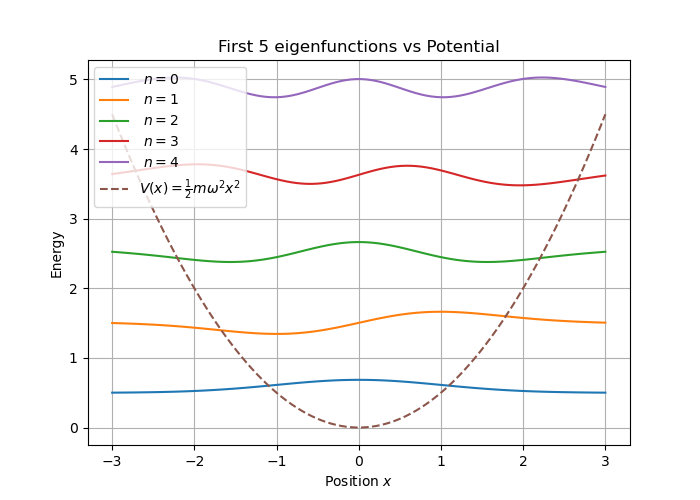

*Figure 1. First 5 wave functions of the harmonic oscillator potential*

#### Problem 2

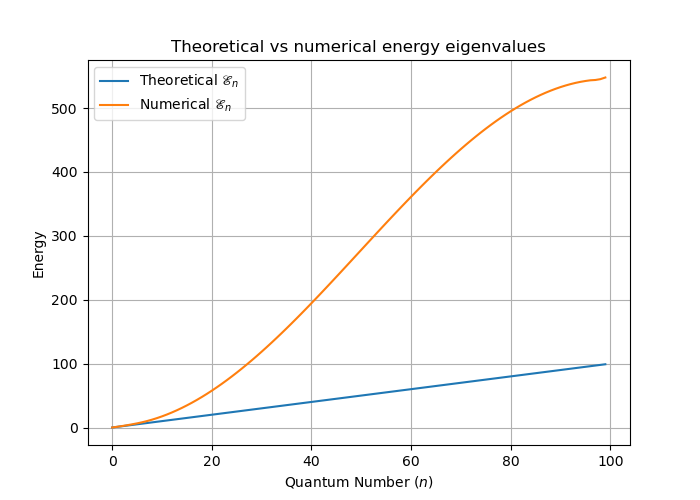

*Figure 2. Theoretical vs numerical energy eigenvalues for a harmonic oscillator potential in an electric field*

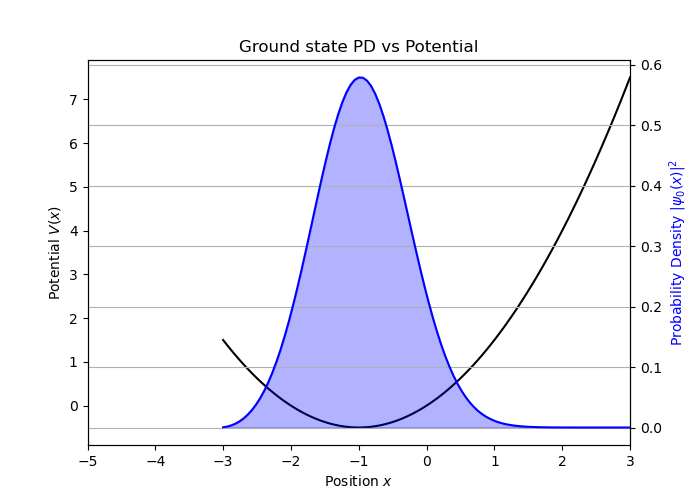

*Figure 3. Ground state probability density vs effective potential for a harmonic oscillator in an electric field*
</div>

### Report discussion
In Problem 2, adding a uniform electric field exerts a constant force on the harmonic oscillator, shifting its potential minimum to $x = -1$ and lowering the energy by a factor of $\frac{1}{2}$.The ground state wavefunction, I obtained the expected Gaussian probability density peak centered precisely at $x = -1$, sitting directly above the new minimum for $V(x)$ which shows that the numerical results are so far theoretically consistent. For the energy eogenvalues, the lower states matched the theoretical values almost perfectly. But for higher eigenvalues, the numerical results started to deviate significantly. This discrepancy occurs because higher energy wavefunctions spread farther out spatially. Since we only considered a finite region of space, the classical turning points for these wave functions actually go beyond the bounds which restricts our solver to approximate a particle in a box instead hence why it overestimates the energy eigenvalues as n becomes larger.

---
## Section 2: Code

### Problem 1: Hamiltonian Matrix and its Eigs

The time-independent Schrödinger equation is:

$$
\left[-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+\hat{V}(x)\right]\psi(x)=\left[\hat{T} + \hat{V} \right]\psi=\mathscr{E}_n\psi(x).
$$

In quantum mechanics, we can represent operators (e.g. $\hat{T}$ and $\hat{V}$) as matrices, while the quantum state (in this case, $\psi$) is written as an $N \times 1$ vector

$$ \psi = 
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix}
$$

where $\psi_i$ represents the value of the wave function at $x_i$. Now, we know that $\left[\hat{V}(x)\psi(x)\right]|_{x_i} \equiv V(x_i)\psi(x_i) = V_i \psi_i$. We can write this statement as:

$$\hat{V}
\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = 
\begin{bmatrix}
V_1\psi_1 \\
V_2\psi_2 \\
\vdots \\
V_i\psi_i \\
\vdots \\
V_N\psi_N
\end{bmatrix}
$$

This relation only holds true when $\hat{V}$ is an $N \times N$ square diagonal matrix of the form:

$$
\boxed{\hat{V}=
\begin{pmatrix}
V_1 & 0 & 0 & \cdots & 0 & 0 & 0 \\
0 & V_2 & 0 & \cdots & 0 & 0 & 0 \\
0 & 0 & V_3 & \cdots & 0 & 0 & 0 \\
\vdots & \vdots & \vdots & \ddots & \vdots & \vdots & \vdots \\
0 & 0 & 0 & \cdots & V_i & 0 & 0 \\
0 & 0 & 0 & \cdots & 0 & \ddots & 0 \\
0 & 0 & 0 & \cdots & 0 & 0 & V_N
\end{pmatrix}
}
$$

where $V_i$ denotes the potential's value at $x_i$. This is then what we call the "matrix representation" of the operator $\hat{V}$! At least, in the position basis -- more info on 142 or 241 :)

**(a)** On a piece of paper, find the matrix representation of the kinetic energy operator $\hat{T} \equiv \cfrac{-\hbar^2}{2m}\cfrac{\partial^2}{\partial x^2}$. Use the fact that 

$$
f''(x_i)=
\frac{f(x_{i+1}) - 2f(x_i) + f(x_{i-1})}{(\Delta x)^2}
$$

The first step of this problem would be to solve
      
\cfrac{\partial^2}{\partial x^2}\begin{bmatrix}
\psi_1 \\
\psi_2 \\
\vdots \\
\psi_i \\
\vdots \\
\psi_N
\end{bmatrix} = \ ?
$$

and then to find a matrix representation for $\cfrac{\partial^2}{\partial x^2}$ operator. Your result should look like a square diagonal matrix

$$
\boxed{\hat{T}=
-\frac{\hbar^2}{2m(\Delta x)^2}
\begin{pmatrix}
-2 & 1 & 0 & 0 & 0 & \cdots & 0 \\
1 & -2 & 1 & 0 & 0 & \cdots & 0 \\
0 & 1 & -2 & 1 & 0 & \cdots & 0 \\
0 & 0 & 1 & -2 & 1 & \ddots & \vdots \\
0 & 0 & 0 & 1 & -2 & \ddots & 0 \\
\vdots & \vdots & \vdots & \ddots & \ddots & \ddots & 1 \\
0 & 0 & 0 & \cdots & 0 & 1 & -2
\end{pmatrix}
}
$$

**(b)** Write a function that outputs the Hamiltonian ($\hat{T} + \hat{V})$ matrix `hamiltonian(x_pos, potential_array, mass)` where `x_pos` and `potential_array` are both $N \times 1$ arrays (vectors), while `mass` is a scalar. The former represents position coordinates while the latter represents potential values at these coordinates. You might want to use `np.eye()`.

**(c)** Test your `hamiltonian()` function for the case where $V(x) = \cfrac{1}{2}m\omega^2x^2$. Obtain the first $N=5$ eigenfunctions of your Hamiltonian using `np.linalg.eigh()`, and obtain their corresponding eigenvalues. Plot the eigenfunctions, then offset each to its corresponding eigenvalue. In essence, you will plot $f_n$ where

$$
f_n = \psi_n + \mathscr{E}_n
$$

Lastly, overlay the harmonic potential $V$ on the plot itself. Assume that $m=\hbar=1$ while $\omega=0.8$. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
 
N = 100
hbar = 1
m = 1
omega = 1

x = np.linspace (-3, 3, N)
delta_x = np.ptp(x)/(N-1) #grid spacing
potential_array = 0.5 * m * (omega**2) * (x**2)

# Constructing the Hamiltonian matrix
def hamiltonian(x, potential_array, mass): 
    T_constants = -(hbar**2) / ((2*m)) # Constants
    T_matrix =(-2 * np.eye(N, k=0)) + np.eye(N, k=1) + np.eye(N, k=-1) # Banded matrix from the second derivative
    kinetic = (T_constants / (delta_x)**2) * T_matrix # Kinetic energy component

    potential = potential_array * np.eye(N, k=0) # Potential component * NxN identity matrix
    hamiltonian = kinetic + potential

    return(hamiltonian)

hamiltonian_matrix = hamiltonian(x, potential_array, m)
eigenvalues, eigenvectors = np.linalg.eigh(hamiltonian_matrix) # Obtain eigenvalues and eigenvectors
print(f"Eigenvalues:", eigenvalues)
print(f"Eigenvectors:", eigenvectors)


Eigenvalues: [5.00163557e-01 1.50394117e+00 2.53045856e+00 3.63026117e+00
 4.87672092e+00 6.33241050e+00 8.03041023e+00 9.98201803e+00
 1.21890611e+01 1.46501837e+01 1.73630002e+01 2.03247162e+01
 2.35322941e+01 2.69824894e+01 3.06718558e+01 3.45967419e+01
 3.87532886e+01 4.31374275e+01 4.77448811e+01 5.25711638e+01
 5.76115847e+01 6.28612499e+01 6.83150669e+01 7.39677483e+01
 7.98138162e+01 8.58476075e+01 9.20632787e+01 9.84548114e+01
 1.05016018e+02 1.11740547e+02 1.18621889e+02 1.25653386e+02
 1.32828231e+02 1.40139482e+02 1.47580064e+02 1.55142777e+02
 1.62820303e+02 1.70605214e+02 1.78489977e+02 1.86466962e+02
 1.94528452e+02 2.02666648e+02 2.10873674e+02 2.19141591e+02
 2.27462399e+02 2.35828047e+02 2.44230442e+02 2.52661455e+02
 2.61112928e+02 2.69576684e+02 2.78044535e+02 2.86508288e+02
 2.94959754e+02 3.03390756e+02 3.11793137e+02 3.20158767e+02
 3.28479553e+02 3.36747444e+02 3.44954440e+02 3.53092600e+02
 3.61154051e+02 3.69130991e+02 3.77015703e+02 3.84800557e+02
 3.92478020

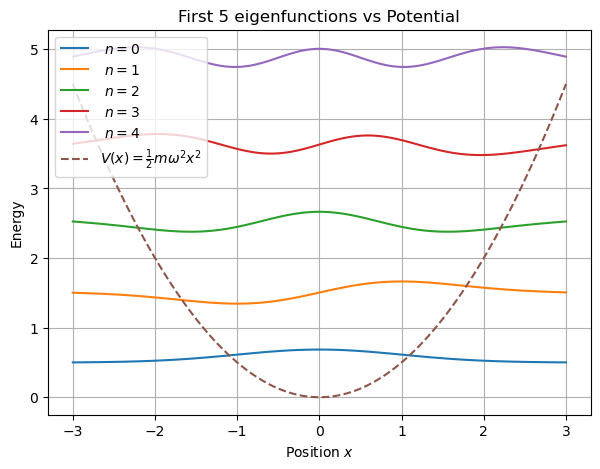

In [12]:
fig, ax = plt.subplots(figsize = (7,5))

for i in range (5):
    ax.plot(x, eigenvectors[:,i] + eigenvalues[i], label = f" $n={i}$")
ax.plot(x, potential_array, '--', label = r'$ V(x)= \frac{1}{2}m\omega^2x^2$')
ax.set_title('First 5 eigenfunctions vs Potential')
ax.set_xlabel('Position $x$')
ax.set_ylabel('Energy')
ax.legend(loc="upper left")
ax.grid()

plt.savefig('Figures/E6P1A.png')
fig.show()

#### Problem 1 code summary

The code in problem 1 solves the time-independent Schrodinger equation for a harmonic oscillator potential to obtain the energy eigenvalues and eigenfunctions. It writes the hamiltonian $\hat{H}$ as a function "hamiltonian()" which takes in the x-values, potential array, and the mass as its arguments, as the sum of two matrices, the kinetic energy component which is an $N \times N$ second derivative matrix divided by grid spacing and scaled by some constant and the potential matrix; this uses the np.eye() function since these are just banded/diagonal matrices. Then, we obtain the eigenvalue equation $\hat H\psi=E_n\psi$; we use the np.linalg.eigh() function to obtain the first $N=100$ energy eigenvalues and eigenvectors. We used .eigh() instead of .eig() since this always gives real eigenvalues as its output.

---

### Problem 2: Harmonic Oscillator in an Electric Field

The effective potential of an oscillator immersed in a uniform electric field is

$$
V(x) = \cfrac{1}{2}m\omega^2x^2 + qEx
$$

where $q$ is the particle's charge, and $E$ is the strength of the applied uniform electric field.

**(a)** Assume that the particle is an electron and it is immersed in a field of strength $E=q^{-1}$. Plot 100 eigenenergies of the resulting Hamiltonian, and compare it with the theoretical value of

$$
\mathscr{E}_n = \hbar \omega \left(n+\cfrac{1}{2} \right) - \cfrac{q^2 E^2}{2m \omega^2}
$$

Did you get the expected result? Why or why not?

theoretical eigenvalues = [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17.
 18. 19. 20. 21. 22. 23. 24. 25. 26. 27. 28. 29. 30. 31. 32. 33. 34. 35.
 36. 37. 38. 39. 40. 41. 42. 43. 44. 45. 46. 47. 48. 49. 50. 51. 52. 53.
 54. 55. 56. 57. 58. 59. 60. 61. 62. 63. 64. 65. 66. 67. 68. 69. 70. 71.
 72. 73. 74. 75. 76. 77. 78. 79. 80. 81. 82. 83. 84. 85. 86. 87. 88. 89.
 90. 91. 92. 93. 94. 95. 96. 97. 98. 99.]
eigenvalues  = [1.43524483e-02 1.09467292e+00 2.28336653e+00 3.57623141e+00
 4.96238918e+00 6.46817728e+00 8.15813344e+00 1.00858216e+01
 1.22710726e+01 1.47155631e+01 1.74160417e+01 2.03685101e+01
 2.35690186e+01 2.70136985e+01 3.06986803e+01 3.46200223e+01
 3.87736619e+01 4.31553852e+01 4.77608083e+01 5.25853668e+01
 5.76243099e+01 6.28726979e+01 6.83254028e+01 7.39771088e+01
 7.98223159e+01 8.58553428e+01 9.20703314e+01 9.84612512e+01
 1.05021905e+02 1.11745932e+02 1.18626818e+02 1.25657896e+02
 1.32832357e+02 1.40143254e+02 1.47583507e+02 1.55145914e+02
 1.

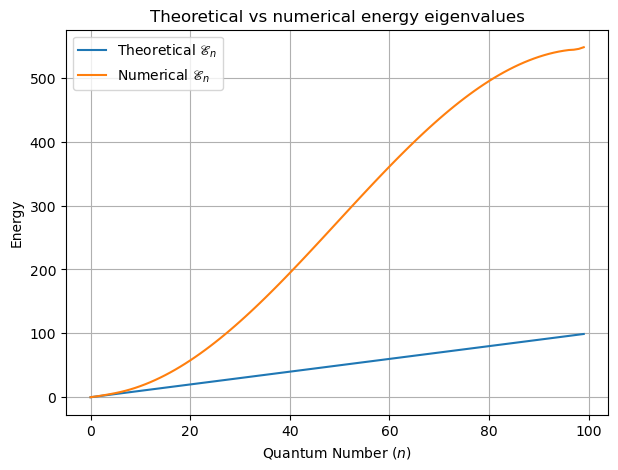

In [10]:
#Assumptions
q = 1
E = 1/q

n = 100 
potential_array2 = 0.5* m * omega**2 * x**2 + q * E * x

evalues_2, evectors_2 = np.linalg.eigh(hamiltonian(x, potential_array2, m))

indices = np.arange(n) # First 100 eigenstates
theo_evalue = hbar * omega * (indices + 0.5) - (q**2 * E**2) / (2 * m * omega**2)

print(f"theoretical eigenvalues =", theo_evalue)
print(f"eigenvalues  =", evalues_2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(indices, theo_evalue, label="Theoretical $\mathscr{E}_n$")
ax.plot(indices, evalues_2[:n], label="Numerical $\mathscr{E}_n$")

ax.set_xlabel("Quantum Number ($n$)")
ax.set_ylabel("Energy")
ax.set_title("Theoretical vs numerical energy eigenvalues")
ax.legend()
ax.grid(True)

plt.savefig('Figures/E6P2A.png')
plt.show()

I did not get the expected results since it shows that as n grows larger, the code begins to overestimate the numerical eigenvalues unlike the theoretical eigenvalues which increases linearly. This may because we only considered a discrete grid $x \in [-3,3]$ which puts the harmonic oscillator potential in a box, since for larger eigenvalues, the classical turning points extend past the grid we defined.

**(b)** Plot the potential and the probability density of the ground state. Does the plot make sense? 

The np.linalg.eigh() gives discretely normalized eigenvectors, i.e.
$$\sum_{i=1}^{N}|e_i|^2=1$$
We approximate the normalization condition by
$$\int|\psi|^2dx = \sum_{i=1}^{N}|\psi|^2\Delta x = 1$$
We get
$$|\psi(x_i)|^2=\frac{|v_i|^2}{\Delta x}$$

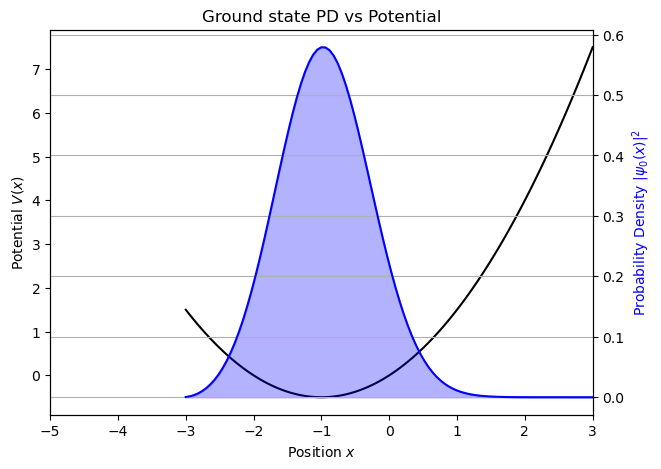

In [11]:
psi0 = evectors_2[:,0]
prob_density0 = np.abs(psi0)**2 / delta_x # divide by delta_x since the np.linalg.eigh gives normalized eigenvectors to obtain a continuous PD

fig, ax1 = plt.subplots(figsize=(7, 5))

# Plot Potential V(x)
ax1.plot(x, potential_array2, "k-", label="Potential $V(x)$")
ax1.set_xlabel("Position $x$")
ax1.set_ylabel("Potential $V(x)$", color="k")
ax1.set_xlim(-5, 3)

# Probability Density
ax2 = ax1.twinx() # make a twin plot for probability so we get a y-axis as the probability
ax2.plot(x, prob_density0, "b-", label=r"$|\psi_0(x)|^2$")
ax2.fill_between(x, 0, prob_density0, color="blue", alpha=0.3)
ax2.set_ylabel(r"Probability Density $|\psi_0(x)|^2$", color="blue")
ax2.grid()
plt.title("Ground state PD vs Potential")
plt.savefig('Figures/E6P2B.png')
fig.show()

Yes, the plot makes sense because the potential we considered for this problem is 

$$V(x) = \frac{1}{2} m\omega^2x^2 + qEx$$.

Finding the minumum at of the potential

$$\frac{dV}{dx} = 0$$
$$m\omega^2x-qE = 0$$
$$x_o=\frac{-qE}{m\omega^2}=-1$$

Which is consistent with the plot since the bottom of $V(x)$ is at $x=-1$.
Since the probability density of finding a particle in the ground state peaks at the minimum (for bounded systems like the SHO), then it follows that the probability density also peaks at $x=-1$. 

#### Problem 2 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---
The code for Problem 2 uses the same hamiltonian() function but uses a new potential array to account for the electric field contribution in the effective potential. Then the first 100 energy eigenvalues were plotted as a function of the principal quantum number for both the theoretical and numerically obtained values. Next, the probability density for the ground state wave function $\psi_0$ was plotted. Since the np.linalg.eigh() gives discretely normalized eigenvectors, we divide $|\psi_0|^2$ by $\Delta x$ to obtain the probability density. Then the $|\psi_0|^2$ was plotted together with the potential, we used a twin axis for y to describe the probability and the energy.

## Section 3 (Notes)

### Some codes for solving matrix problems

* solving matrix equations ($\bf{A}\vec{x} = \vec{b}$) -> `np.linalg.solve`
* LU-decomposition ($\bf{A} = \bf{L}\bf{U}$) -> `scipy.linalg.lu`
* matrix inversion ($\bf{A}^{-1}$) -> `np.linalg.inv`
* QR-decomposition ($\bf{A} = \bf{Q}\bf{R}$) -> `scipy.linalg.qr`
* eigenvalue problem ($\bf{A}\vec{x} = \lambda \vec{x}$) -> `np.linalg.eig`

Solving matrix problems by themselves isn't difficult. There is an abundance of linear algebra libraries that are ready to use: from the battle-tested ones (the classic [BLAS](https://www.netlib.org/blas/) and [LAPACK](https://www.netlib.org/lapack/)), HPC tools for large problems ([ScaLAPACK](https://netlib.org/scalapack/)), to hardware-accelerated ones often with GPUs ([cuBLAS](https://docs.nvidia.com/cuda/cublas/index.html) and [cuSolver](https://docs.nvidia.com/cuda/cusolver/index.html) for NVIDIA). 

The hardest part is actually composing the matrix. How do you transform a physical problem into a linear algebra problem?

* Circuit: https://personal.math.vt.edu/embree/cmda3606/chapter2.pdf
* Embree [main notes](https://personal.math.vt.edu/embree/cmda3606notes.pdf) + [lab manual](https://personal.math.vt.edu/embree/labman.pdf)